# EMG Windowing and Feature Extraction

**Objective:** Segment labeled sEMG recordings into fixed-duration windows and extract interpretable time-domain features for gesture classification.

**Dataset:** UCI EMG Data for Gestures  
**Sampling assumption:** 200 Hz  
**Window size:** 200 ms (40 samples)  
**Window overlap:** 50% (20-sample step)  
**Scope:** Educational and research demonstration only; not for clinical use.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt

In [2]:
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded))

df = pd.read_csv(filename, sep="\t")

df.columns = [
    "time",
    "channel_1",
    "channel_2",
    "channel_3",
    "channel_4",
    "channel_5",
    "channel_6",
    "channel_7",
    "channel_8",
    "gesture"
]

df["gesture"] = pd.to_numeric(df["gesture"])
channels = [f"channel_{i}" for i in range(1, 9)]

print("Data shape:", df.shape)
print("Gesture classes:", sorted(df["gesture"].unique()))

Saving 1_raw_data_10-38_11.04.16.txt to 1_raw_data_10-38_11.04.16.txt
Data shape: (51078, 10)
Gesture classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [3]:
fs = 200
lowcut = 20
highcut = 80
filter_order = 4

def bandpass_filter(signal, fs, lowcut, highcut, order=4):
    nyquist = fs / 2
    b, a = butter(
        order,
        [lowcut / nyquist, highcut / nyquist],
        btype="bandpass"
    )
    return filtfilt(b, a, signal)

In [4]:
def root_mean_square(signal):
    return np.sqrt(np.mean(np.square(signal)))

def mean_absolute_value(signal):
    return np.mean(np.abs(signal))

def waveform_length(signal):
    return np.sum(np.abs(np.diff(signal)))

def zero_crossings(signal, threshold=1e-7):
    centered = signal - np.mean(signal)
    crossings = np.diff(np.signbit(centered))
    amplitude_change = np.abs(np.diff(centered)) >= threshold
    return np.sum(crossings & amplitude_change)

feature_functions = {
    "rms": root_mean_square,
    "mav": mean_absolute_value,
    "wl": waveform_length,
    "zc": zero_crossings
}

In [5]:
filtered_df = df.copy()

for channel in channels:
    filtered_df[channel] = bandpass_filter(
        filtered_df[channel].to_numpy(),
        fs=fs,
        lowcut=lowcut,
        highcut=highcut,
        order=filter_order
    )

print("All eight channels filtered.")

All eight channels filtered.


In [6]:
window_ms = 200
overlap = 0.50

window_size = int(fs * window_ms / 1000)
step_size = int(window_size * (1 - overlap))

print(f"Window size: {window_size} samples")
print(f"Step size: {step_size} samples")

feature_rows = []

for start in range(0, len(filtered_df) - window_size + 1, step_size):
    window = filtered_df.iloc[start:start + window_size]

    labels_in_window = window["gesture"].unique()

    if len(labels_in_window) != 1:
        continue

    gesture_label = labels_in_window[0]

    row = {
        "start_time": window["time"].iloc[0],
        "end_time": window["time"].iloc[-1],
        "gesture": gesture_label
    }

    for channel in channels:
        signal = window[channel].to_numpy()

        for feature_name, feature_function in feature_functions.items():
            row[f"{channel}_{feature_name}"] = feature_function(signal)

    feature_rows.append(row)

features_df = pd.DataFrame(feature_rows)

print("Feature table shape:", features_df.shape)
display(features_df.head())

Window size: 40 samples
Step size: 20 samples
Feature table shape: (2506, 35)


,start_time,end_time,gesture,channel_1_rms,channel_1_mav,channel_1_wl,channel_1_zc,channel_2_rms,channel_2_mav,channel_2_wl,...,channel_6_wl,channel_6_zc,channel_7_rms,channel_7_mav,channel_7_wl,channel_7_zc,channel_8_rms,channel_8_mav,channel_8_wl,channel_8_zc
0,1,55,0,0.000004,0.000003,0.000103,13,0.000007,0.000004,0.000224,...,0.000156,9,0.000002,9.948769e-07,0.000058,11,0.000004,0.000002,0.000086,10
1,24,75,0,0.000005,0.000004,0.000180,13,0.000008,0.000005,0.000284,...,0.000313,11,0.000003,1.952810e-06,0.000117,15,0.000005,0.000003,0.000167,17
2,56,98,0,0.000004,0.000002,0.000127,18,0.000006,0.000003,0.000117,...,0.000175,11,0.000002,1.206813e-06,0.000055,12,0.000005,0.000002,0.000141,15
3,76,119,0,0.000006,0.000003,0.000173,12,0.000004,0.000002,0.000128,...,0.000183,20,0.000002,1.385403e-06,0.000057,9,0.000003,0.000002,0.000096,12
4,99,140,0,0.000006,0.000004,0.000191,11,0.000004,0.000002,0.000122,...,0.000156,18,0.000003,2.150364e-06,0.000082,9,0.000004,0.000002,0.000126,10


Windows per gesture class:
gesture
0    1511
1     165
2     162
3     159
4     160
5     193
6     156
Name: count, dtype: int64


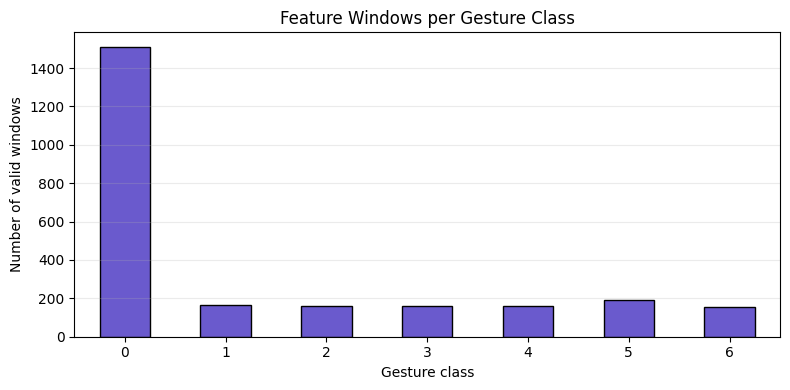

In [7]:
window_counts = features_df["gesture"].value_counts().sort_index()

print("Windows per gesture class:")
print(window_counts)

plt.figure(figsize=(8, 4))
window_counts.plot(kind="bar", color="slateblue", edgecolor="black")
plt.title("Feature Windows per Gesture Class")
plt.xlabel("Gesture class")
plt.ylabel("Number of valid windows")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

Windows retained per class: 156

Balanced window counts:
gesture
0    156
1    156
2    156
3    156
4    156
5    156
6    156
Name: count, dtype: int64


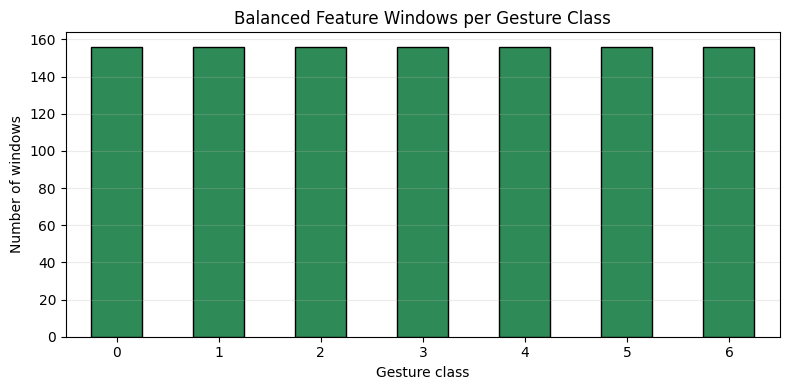

In [8]:
random_seed = 42

min_class_count = features_df["gesture"].value_counts().min()

balanced_features_df = (
    features_df
    .groupby("gesture", group_keys=False)
    .sample(n=min_class_count, random_state=random_seed)
    .sample(frac=1, random_state=random_seed)
    .reset_index(drop=True)
)

balanced_counts = balanced_features_df["gesture"].value_counts().sort_index()

print(f"Windows retained per class: {min_class_count}")
print("\nBalanced window counts:")
print(balanced_counts)

plt.figure(figsize=(8, 4))
balanced_counts.plot(kind="bar", color="seagreen", edgecolor="black")
plt.title("Balanced Feature Windows per Gesture Class")
plt.xlabel("Gesture class")
plt.ylabel("Number of windows")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

In [9]:
metadata_columns = ["start_time", "end_time", "gesture"]

X = balanced_features_df.drop(columns=metadata_columns)
y = balanced_features_df["gesture"]

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)
print("\nFirst 10 feature names:")
print(X.columns[:10].tolist())

display(X.head())

Feature matrix shape: (1092, 32)
Label vector shape: (1092,)

First 10 feature names:
['channel_1_rms', 'channel_1_mav', 'channel_1_wl', 'channel_1_zc', 'channel_2_rms', 'channel_2_mav', 'channel_2_wl', 'channel_2_zc', 'channel_3_rms', 'channel_3_mav']


,channel_1_rms,channel_1_mav,channel_1_wl,channel_1_zc,channel_2_rms,channel_2_mav,channel_2_wl,channel_2_zc,channel_3_rms,channel_3_mav,...,channel_6_wl,channel_6_zc,channel_7_rms,channel_7_mav,channel_7_wl,channel_7_zc,channel_8_rms,channel_8_mav,channel_8_wl,channel_8_zc
0,0.000063,0.000046,0.001649,13,0.000012,0.000008,0.000289,12,0.000004,0.000003,...,0.000409,10,0.000038,0.000024,0.000872,12,0.000047,0.000034,0.001190,12
1,0.000004,0.000002,0.000120,17,0.000007,0.000003,0.000158,10,0.000011,0.000005,...,0.000107,11,0.000003,0.000001,0.000059,8,0.000005,0.000003,0.000101,11
2,0.000003,0.000002,0.000075,10,0.000004,0.000002,0.000083,13,0.000004,0.000002,...,0.000126,11,0.000004,0.000003,0.000104,11,0.000005,0.000003,0.000117,11
3,0.000020,0.000012,0.000393,11,0.000034,0.000024,0.000834,11,0.000071,0.000048,...,0.000293,9,0.000004,0.000003,0.000094,9,0.000006,0.000004,0.000157,11
4,0.000016,0.000011,0.000475,11,0.000014,0.000010,0.000438,12,0.000019,0.000012,...,0.001523,19,0.000017,0.000012,0.000484,15,0.000027,0.000018,0.000885,15


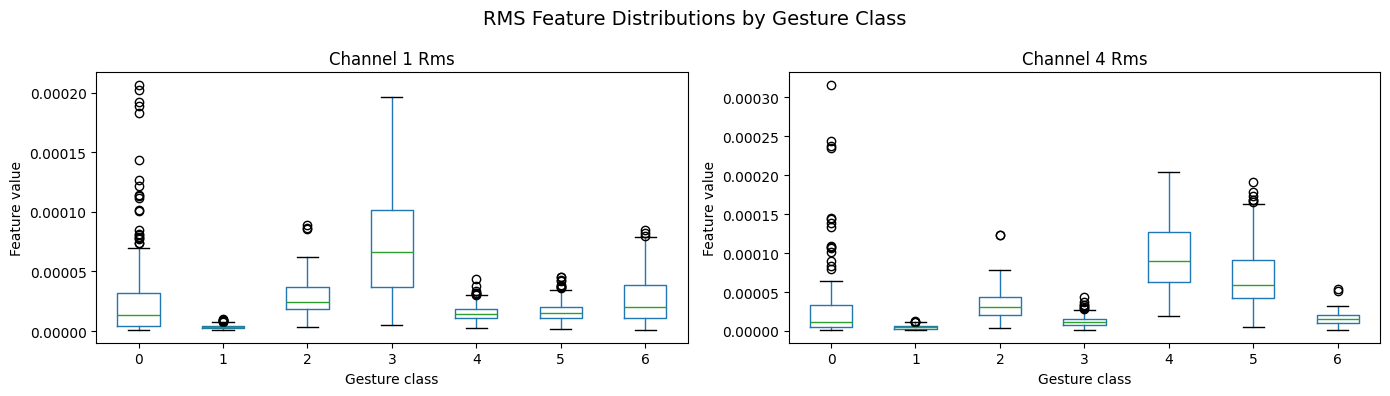

In [10]:
plot_features = ["channel_1_rms", "channel_4_rms"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, feature in zip(axes, plot_features):
    balanced_features_df.boxplot(
        column=feature,
        by="gesture",
        ax=ax,
        grid=False
    )
    ax.set_title(feature.replace("_", " ").title())
    ax.set_xlabel("Gesture class")
    ax.set_ylabel("Feature value")

plt.suptitle("RMS Feature Distributions by Gesture Class", fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

lda_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LinearDiscriminantAnalysis())
])

lda_pipeline.fit(X_train, y_train)

y_pred = lda_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Training windows: {len(X_train)}")
print(f"Test windows: {len(X_test)}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Macro F1: {macro_f1:.3f}")

Training windows: 819
Test windows: 273
Accuracy: 0.681
Macro F1: 0.668


In [13]:
print(
    classification_report(
        y_test,
        y_pred,
        digits=3,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0      0.241     0.179     0.206        39
           1      0.672     1.000     0.804        39
           2      0.833     0.769     0.800        39
           3      0.711     0.692     0.701        39
           4      0.839     0.667     0.743        39
           5      0.719     0.590     0.648        39
           6      0.694     0.872     0.773        39

    accuracy                          0.681       273
   macro avg      0.673     0.681     0.668       273
weighted avg      0.673     0.681     0.668       273



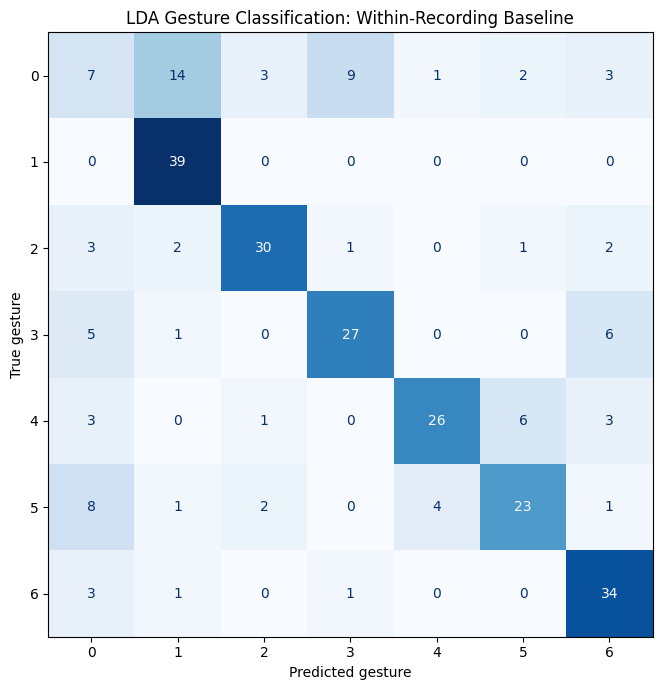

In [14]:
fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=sorted(y.unique()),
    cmap="Blues",
    colorbar=False,
    ax=ax
)

ax.set_title("LDA Gesture Classification: Within-Recording Baseline")
ax.set_xlabel("Predicted gesture")
ax.set_ylabel("True gesture")

plt.tight_layout()
plt.show()

## Baseline Classification Results

A standardized Linear Discriminant Analysis (LDA) classifier was trained on 32 time-domain features: RMS, mean absolute value, waveform length, and zero crossings across eight EMG channels.

Using a stratified 75/25 split of a class-balanced feature table, the within-recording baseline achieved:

- Accuracy: 0.681
- Macro F1: 0.668

Gesture classes 1 and 2 produced the strongest F1 scores (0.804 and 0.800), while the rest class (0) produced the weakest F1 score (0.206).

This evaluation is exploratory. The source windows overlap by 50%, so neighboring windows may contain highly similar signal content. The results should not be interpreted as independent-trial, cross-session, cross-user, real-time, or clinical performance.

In [15]:
results_summary = pd.DataFrame({
    "metric": ["accuracy", "macro_f1"],
    "value": [accuracy, macro_f1]
})

display(results_summary)

,metric,value
0,accuracy,0.681319
1,macro_f1,0.667825
